In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('../data/team_stats_2003_2023.csv')
df.head()

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,...,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,...,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,...,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
3,2003,New York Jets,6,10,0.375,283,299,-16,-1.0,16,...,8,4.0,78,69,550,15,32.4,11.8,-107.89,NaN
4,2003,Baltimore Ravens,10,6,0.625,391,281,110,6.9,16,...,18,4.8,115,126,970,23,31.8,16.6,-220.50,NaN


In [8]:
target = 'win_loss_perc'

exclude_cols = ['year', 'team', 'wins', 'losses', target, 'ties', 'points_diff', 'mov']

df_clean = df.drop(columns=[col for col in exclude_cols if col in df.columns])

df_clean = df_clean.dropna()
df_clean.head()

,points,points_opp,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,...,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot
0,348,238,16,5039,1042,4.8,24,11,294,320,...,1607,9,3.4,91,111,998,26,27.9,11.3,-136.51
1,311,261,16,4609,968,4.8,34,15,266,257,...,1817,14,3.7,99,103,913,22,28.1,17.2,-177.92
2,243,279,16,4348,980,4.4,34,17,268,293,...,1664,13,3.9,96,106,891,22,21.9,17.6,-230.07
3,283,299,16,4951,936,5.3,20,6,274,312,...,1635,8,4.0,78,69,550,15,32.4,11.8,-107.89
4,391,281,16,4929,1009,4.9,38,19,259,217,...,2674,18,4.8,115,126,970,23,31.8,16.6,-220.50


In [9]:
X = df_clean
y = df[target][df_clean.index]

In [10]:
offensive_features = ['points', 'total_yards', 'plays_offense', 'yds_per_play_offense', 
                      'first_down', 'pass_cmp', 'pass_att', 'pass_yds', 'pass_td', 
                      'pass_int', 'pass_net_yds_per_att', 'pass_fd', 'rush_att', 
                      'rush_yds', 'rush_td', 'rush_yds_per_att', 'rush_fd']

defensive_features = ['points_opp', 'turnovers', 'fumbles_lost']

efficiency_features = ['score_pct', 'turnover_pct', 'exp_pts_tot', 'penalties', 
                       'penalties_yds', 'pen_fd']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
## MODELS WE CAN USE

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),

    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),

    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=5,
    min_split_gain=0.0,
    random_state=42,
    verbose=-1
),

    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

In [20]:
def evaluate_model(name, model, X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test):
    scaled_models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']

    if name in scaled_models:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Predictions': y_pred
    }

In [21]:
results = []

for name, model in models.items():
    result = evaluate_model(
        name, model,
        X_train, X_test,
        X_train_scaled, X_test_scaled,
        y_train, y_test
    )
    results.append(result)

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'Predictions'}
    for r in results
]).sort_values(by='R2', ascending=False)

results_df

,Model,MSE,RMSE,MAE,R2
2,Lasso Regression,0.005642,0.075114,0.061829,0.855393
1,Ridge Regression,0.005843,0.076442,0.062738,0.850233
0,Linear Regression,0.005944,0.077095,0.063231,0.847663
4,Gradient Boosting,0.006817,0.082563,0.064848,0.825288
3,Random Forest,0.006845,0.082732,0.065439,0.824574
6,LightGBM,0.006895,0.083035,0.066617,0.823287
5,XGBoost,0.007425,0.086170,0.066524,0.809689
7,SVR,0.007524,0.086743,0.069271,0.807152


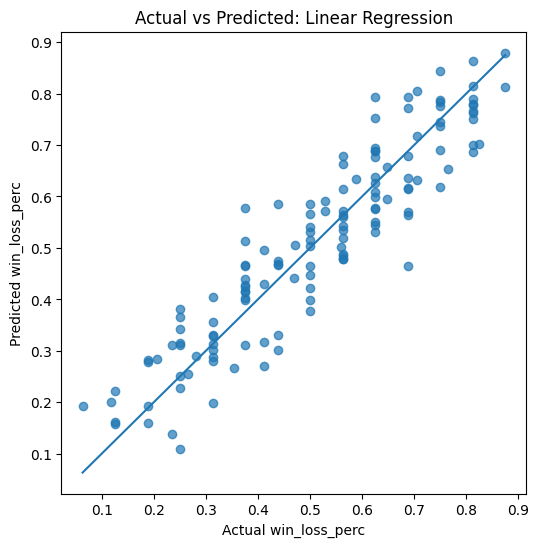

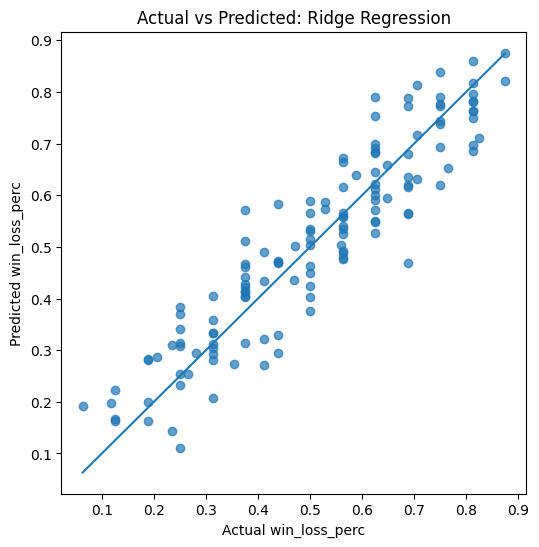

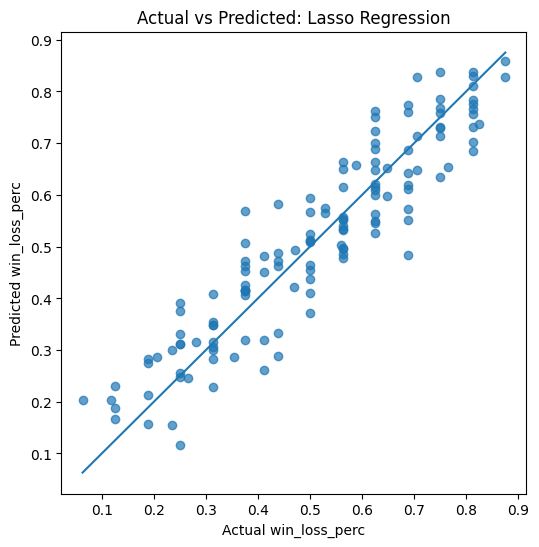

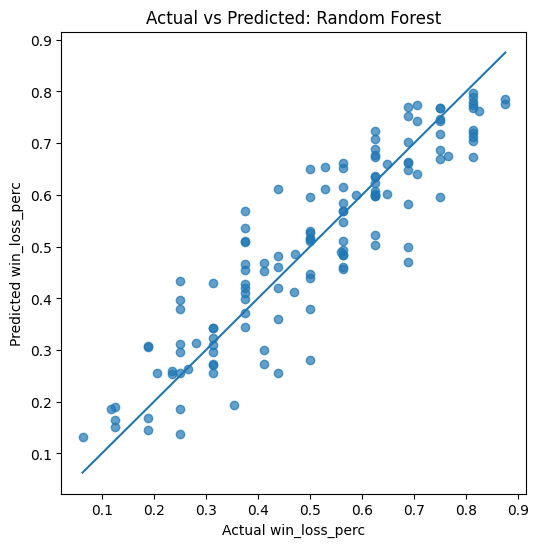

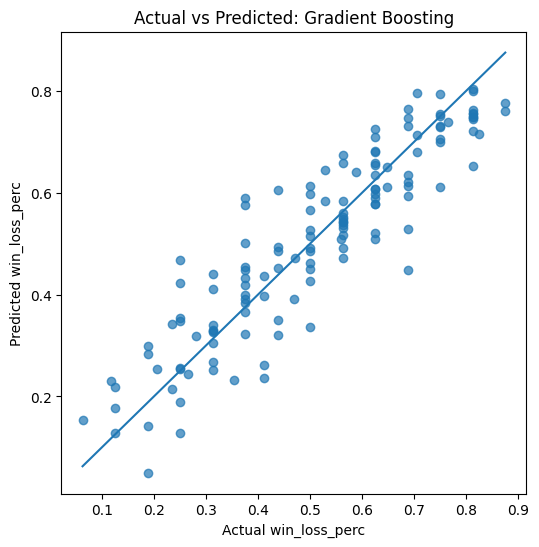

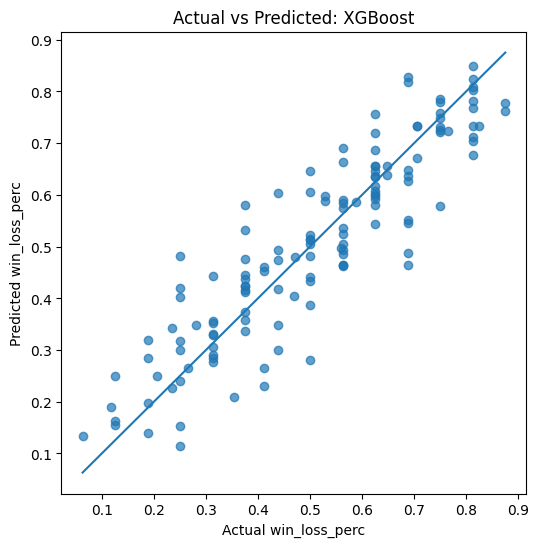

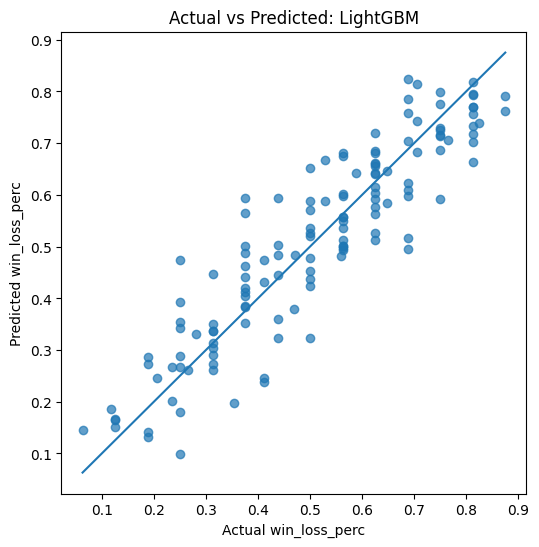

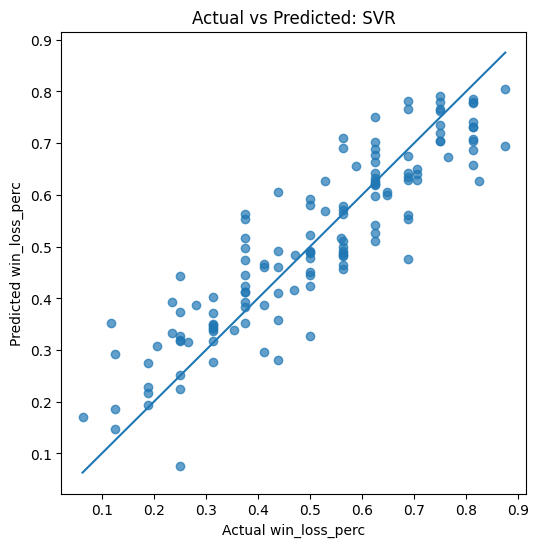

In [23]:
for result in results:
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, result['Predictions'], alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.xlabel("Actual win_loss_perc")
    plt.ylabel("Predicted win_loss_perc")
    plt.title(f"Actual vs Predicted: {result['Model']}")
    plt.show()

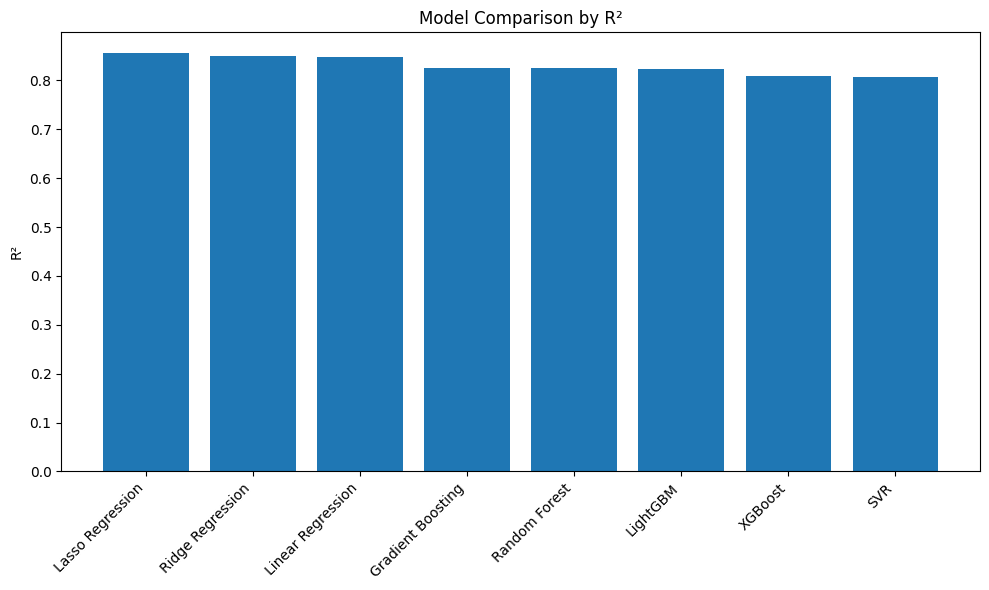

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['R2'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('R²')
plt.title('Model Comparison by R²')
plt.tight_layout()
plt.show()